---
# `Steps of EDA`
---

```code
Dataset
   ↓
Identify Data Types
   ↓
Univariate Analysis
   ↓
Bivariate Analysis
   ↓
Feature Engineering
   ↓
Machine Learning Model
```

---

# `Step 1: Categorize the Columns`

Before analyzing the data, identify the type of each column.

## 1. Numerical Columns

Contains numbers.

### Examples

- Age
- Salary
- Height
- Weight
- Marks

---

## 2. Categorical Columns

Contains categories or labels.

### Examples

- Gender
- City
- Department
- Blood Group

---

## 3. Mixed Columns

Contains both text and numbers.

### Examples

- Product ID (P101)
- Employee ID (EMP001)
- Experience ("5 Years")

---

# `Step 2: Univariate Analysis`

## What is Univariate Analysis?

Univariate Analysis means analyzing **one column at a time**.

Its goal is to understand the distribution and quality of that single feature.

---

# A. Numerical Column Analysis

## 1. Histogram

### Why?

To understand how the values are distributed.

### When to Use?

Use a Histogram when you want to answer:

- Are most values high or low?
- Is the data normally distributed?
- Is the data skewed?

### Example

Age Distribution

```
20-30  ███████
30-40  ███████████
40-50  █████
50-60  ██
```

### Python

```python
sns.histplot(df["Age"])
```

---

## 2. KDE Plot

### Why?

Shows a **smooth version** of the histogram.

It helps understand the overall shape of the data.

### When to Use?

- To check the probability distribution.
- To compare distributions of multiple datasets.

### Example

```
      /\
     /  \
___ /    \____
```

### Python

```python
sns.kdeplot(df["Age"])
```

---

## 3. Box Plot

### Why?

To detect **outliers**.

### When to Use?

Whenever you want to find unusually high or low values.

### Example

```
|-----|=======|------|
          ○
```

The dot (○) is an outlier.

### Python

```python
sns.boxplot(x=df["Salary"])
```

---

## 4. Missing Values

### Why?

Machine Learning models cannot work properly with missing data.

### How?

```python
df.isnull().sum()
```

Then fill missing values using:

- Mean
- Median
- Mode
- Forward Fill
- Backward Fill

---

# B. Categorical Column Analysis

## Count Plot

### Why?

Shows how many records belong to each category.

### When to Use?

Whenever the column contains categories.

### Example

Gender

```
Male      █████████

Female    ██████

Other     ██
```

### Python

```python
sns.countplot(x="Gender", data=df)
```

---

## Missing Values

Check missing categories.

```python
df["Gender"].isnull().sum()
```

Usually fill with:

- Mode
- "Unknown"

---

# `Step 3: Bivariate Analysis`

## What is Bivariate Analysis?

Bivariate Analysis means analyzing **two columns together**.

Purpose:

- Find relationships.
- Compare variables.
- Understand trends.

---

# 1. Numerical vs Numerical

## Scatter Plot

### Why?

Shows the relationship between two numerical columns.

### When to Use?

Examples:

- Age vs Salary
- Height vs Weight
- Experience vs Salary

### Example

```
Salary

|
|      •
|   •
| •
|_________________

      Experience
```

### Python

```python
sns.scatterplot(
    x="Experience",
    y="Salary",
    data=df
)
```

---

# 2. Numerical vs Categorical

## Bar Plot

### Why?

Compares the average numerical value for each category.

### When to Use?

Examples:

- Department vs Average Salary
- City vs Average House Price
- Gender vs Average Marks

### Example

Average Salary

```
HR        █████

IT        ██████████

Sales     ███████
```

### Python

```python
sns.barplot(
    x="Department",
    y="Salary",
    data=df
)
```

---

# 3. Categorical vs Categorical

## Heatmap

### Why?

Shows the relationship between two categorical columns.

### When to Use?

Examples:

- Gender vs Purchased
- Department vs Promotion
- City vs Product Category

### Example

|          | Purchased | Not Purchased |
|----------|------------|---------------|
| Male     | 120 | 40 |
| Female   | 90 | 30 |

Displayed as a heatmap where darker colors represent higher frequencies.

### Python

```python
pd.crosstab(df["Gender"], df["Purchased"])

sns.heatmap(...)
```

---

# `Step 4: Feature Engineering`

After EDA, we improve the data using Feature Engineering.

Examples:

- Handle missing values
- Remove outliers
- Encode categorical data
- Scale numerical data
- Create new features

Then the cleaned data is ready for Machine Learning.

---

# Quick Cheat Sheet

| Column Type | Goal | Graph | Why? |
|-------------|------|--------|------|
| Numerical | Distribution | Histogram | See how data is spread |
| Numerical | Smooth Distribution | KDE Plot | Understand probability distribution |
| Numerical | Outliers | Box Plot | Find unusual values |
| Categorical | Distribution | Count Plot | Count each category |
| Numerical vs Numerical | Relationship | Scatter Plot | Check correlation/trend |
| Numerical vs Categorical | Compare Averages | Bar Plot | Compare numerical values across categories |
| Categorical vs Categorical | Relationship | Heatmap | Compare category combinations |

---

# Easy Memory Trick

📊 **One Column (Univariate)**

- Histogram → Distribution
- KDE → Smooth Distribution
- Box Plot → Outliers
- Count Plot → Category Count

📊 **Two Columns (Bivariate)**

- Number + Number → Scatter Plot
- Number + Category → Bar Plot
- Category + Category → Heatmap

---

# Key Takeaways

- Start EDA by identifying column types.
- Analyze one column using **Univariate Analysis**.
- Analyze two columns using **Bivariate Analysis**.
- Choose the graph based on the type of data.
- EDA helps understand the data before Feature Engineering.
- Better EDA leads to better Machine Learning models.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("../Datasets/titanic.csv")

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 56.1 KB


## `Univariate Analysis on Numerical Column`
- Data Distribution of the numerical column: describe() & Plotting like kdeplot or histogram
- Outliers detection: boxplot
- Imputation

### `Age Column`

In [11]:
df['Age'].describe()

count    332.000000
mean      30.272590
std       14.181209
min        0.170000
25%       21.000000
50%       27.000000
75%       39.000000
max       76.000000
Name: Age, dtype: float64

In [12]:
df[df['Age'] == 76]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
96,988,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.85,C46,S


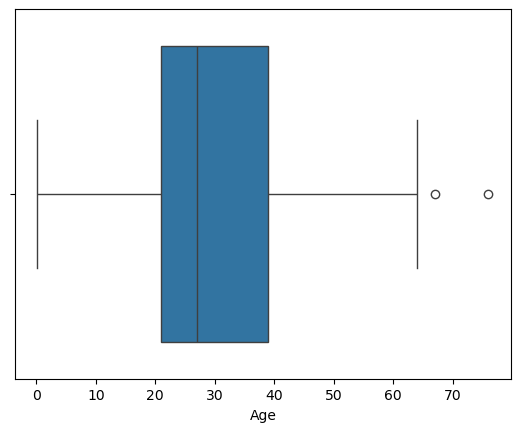

In [15]:
sns.boxplot(data = df, x='Age')
plt.show()

In [16]:
df['Age'].isnull().sum()

np.int64(86)

In [17]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [18]:
df['Age'].isnull().sum()

np.int64(0)

In [20]:
df['Age'].describe()

count    418.000000
mean      29.599282
std       12.703770
min        0.170000
25%       23.000000
50%       27.000000
75%       35.750000
max       76.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

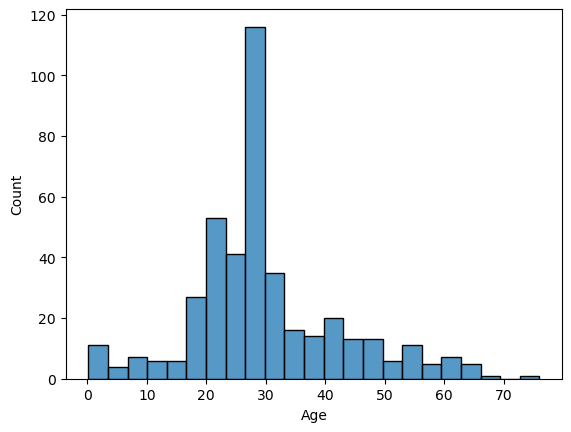

In [21]:
sns.histplot(data = df, x='Age')

<Axes: xlabel='Age', ylabel='Density'>

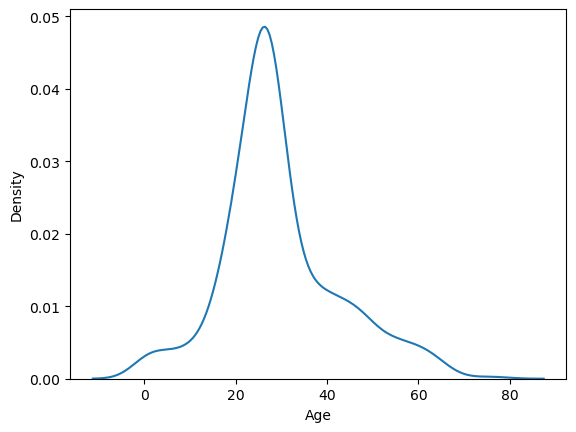

In [22]:
sns.kdeplot(data = df, x='Age')

## `Fair Column`

In [25]:
df['Fare'].isnull().sum()

np.int64(1)

In [26]:
df['Fare'].describe()

count    417.000000
mean      35.627188
std       55.907576
min        0.000000
25%        7.895800
50%       14.454200
75%       31.500000
max      512.329200
Name: Fare, dtype: float64

In [ ]:
df[df['Fare']==512.329200]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
343,1235,1,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C


In [ ]:
df[df['Ticket']=='PC 17755']['Name']
# This is a outlier

343    Cardeza, Mrs. James Warburton Martinez (Charlo...
Name: Name, dtype: str

<Axes: xlabel='Fare'>

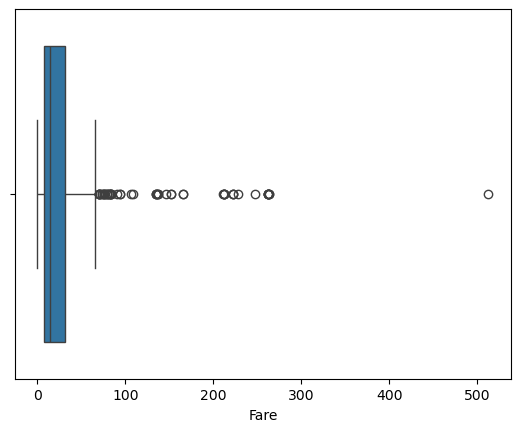

In [30]:
sns.boxplot(data = df, x='Fare')

<Axes: xlabel='Fare', ylabel='Count'>

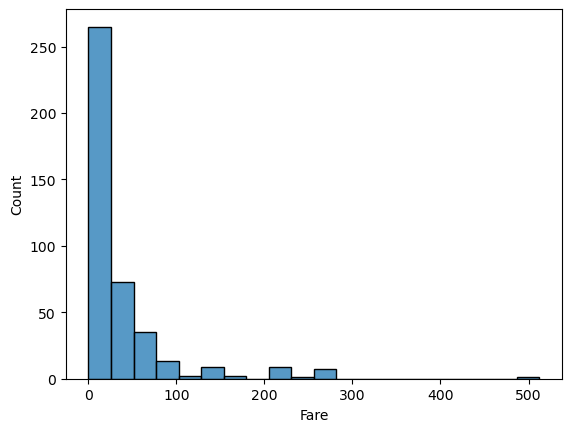

In [31]:
sns.histplot(data = df, x='Fare', bins = 20)

## `Univariate Analysis : Categorical Column`
- Data Distribution: value_counts() --> countplot()
- handle missing values: mode or most frequent imputation

In [32]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [33]:
df['Survived'].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

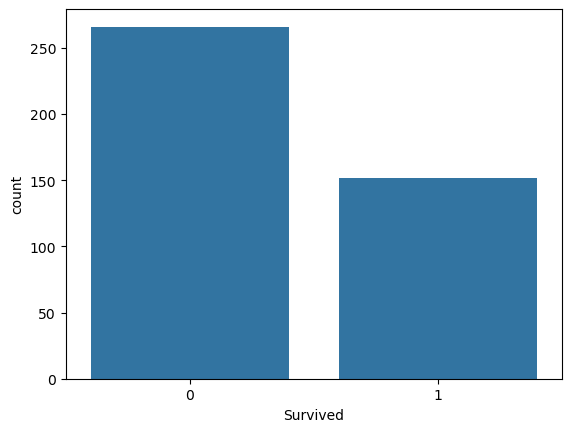

In [34]:
sns.countplot(data = df, x = 'Survived')

In [35]:
df['Survived'].isnull().sum()

np.int64(0)

In [36]:
df['Embarked'].value_counts()

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

<Axes: xlabel='Embarked', ylabel='count'>

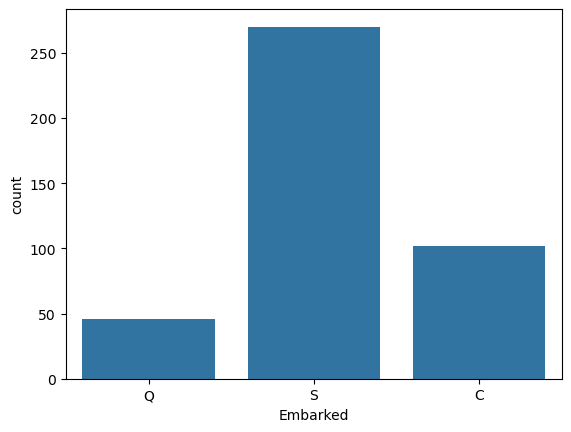

In [37]:
sns.countplot(data=df, x='Embarked')

# Assumption: age value vs fare

<Axes: xlabel='Age', ylabel='Fare'>

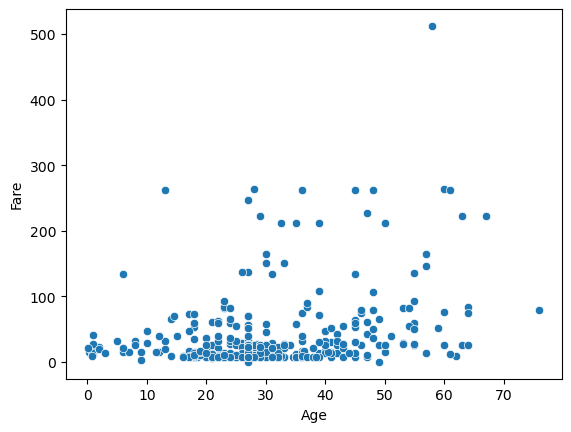

In [38]:
sns.scatterplot(data = df, x = 'Age', y ='Fare')

# Bivariate Analysis: 
- Numerical Numerical 
- Numerical Categoical
- Categorical Categorical

<Axes: xlabel='Pclass', ylabel='Fare'>

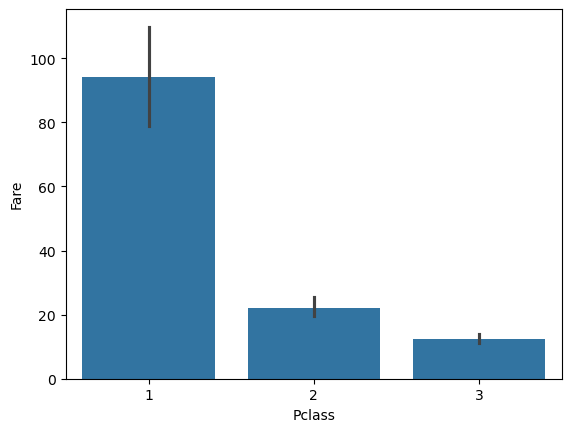

In [39]:
sns.barplot(data=df, x='Pclass', y='Fare')

<Axes: xlabel='Embarked', ylabel='Fare'>

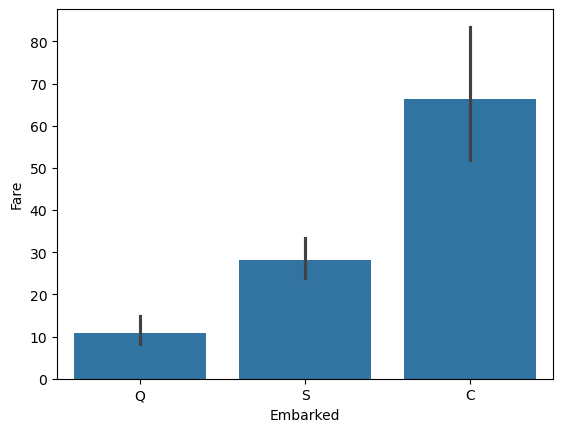

In [40]:
sns.barplot(data=df, x='Embarked', y='Fare')

In [41]:
df['SibSp'].value_counts()

SibSp
0    283
1    110
2     14
3      4
4      4
8      2
5      1
Name: count, dtype: int64

<Axes: xlabel='SibSp', ylabel='Fare'>

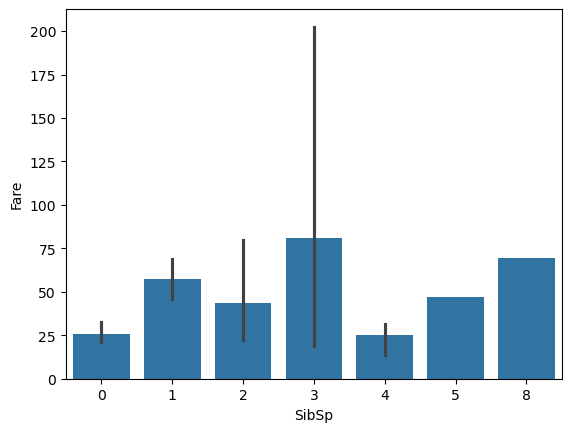

In [42]:
sns.barplot(data=df, x='SibSp',y ='Fare')

<Axes: xlabel='Sex', ylabel='Fare'>

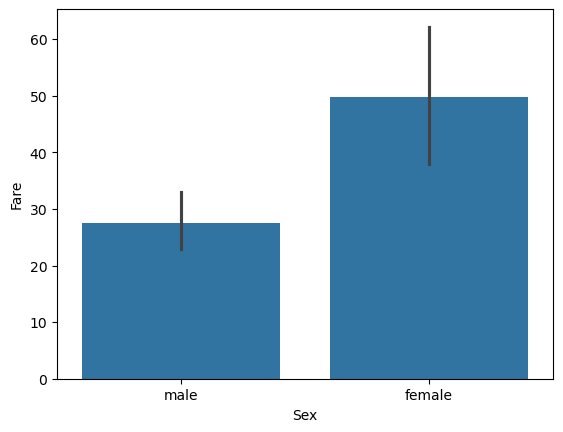

In [43]:
sns.barplot(data=df, x='Sex',y ='Fare')

In [45]:
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,57,50
2,63,30
3,146,72


<Axes: xlabel='Survived', ylabel='Pclass'>

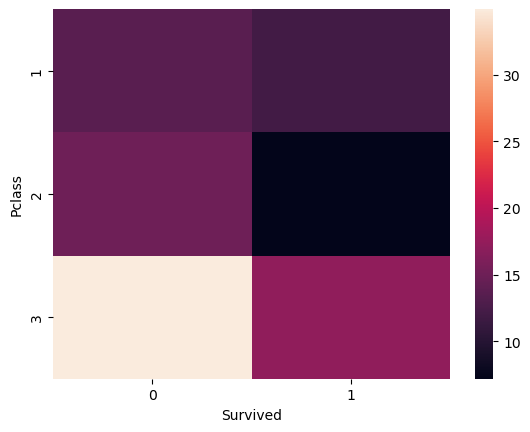

In [47]:
sns.heatmap(pd.crosstab(df['Pclass'], df['Survived'], normalize=True)*100)

In [49]:
pd.crosstab(df['Sex'], df['Survived'], normalize=True)*100

Survived,0,1
Sex,,
female,0.000000,36.363636
male,63.636364,0.000000


In [50]:
df['Sex'].value_counts()

Sex
male      266
female    152
Name: count, dtype: int64

In [51]:
pd.crosstab(df['Embarked'], df['Survived'], normalize=True)*100

Survived,0,1
Embarked,,
C,14.832536,9.569378
Q,5.263158,5.741627
S,43.540670,21.052632


<Axes: xlabel='Survived', ylabel='Embarked'>

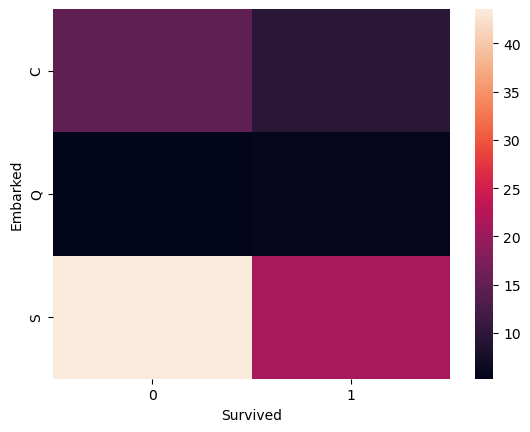

In [52]:
sns.heatmap(pd.crosstab(df['Embarked'], df['Survived'], normalize=True)*100)